# EFW Quinquennial (1970–2020) × Elections × Macro (Presentable)

Builds the quinquennial EFW panel, aligns elections with two timing rules, merges macro, and produces descriptive diagnostics.

In [1]:

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import yaml
from datetime import datetime
from IPython.display import display

pd.options.mode.copy_on_write = True

%matplotlib inline


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    raise ValueError('Repo root not found; expected data/ and notebooks/ in a parent directory')

ROOT = find_repo_root()

PATHS = {
    'data_processed': ROOT / 'data' / 'processed',
    'data_raw': ROOT / 'data' / 'raw',
    'reports': ROOT / 'reports',
}


def read_parquet_pyarrow(path: str | Path) -> pd.DataFrame:
    table = pq.read_table(str(path))
    return table.to_pandas()


def write_parquet_pyarrow(df: pd.DataFrame, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, str(path))


AUDIT_LOG = []


def log_df(df: pd.DataFrame, step: str, keys: list[str] | None = None, notes: str = "") -> None:
    row = {
        'step': step,
        'n_rows': int(len(df)),
        'n_cols': int(df.shape[1]),
        'n_iso3': int(df['iso3'].nunique(dropna=True)) if 'iso3' in df.columns else None,
        'notes': notes,
    }
    if keys:
        row['n_dupe_rows_on_keys'] = int(df.duplicated(subset=keys).sum())
    AUDIT_LOG.append(row)


def assert_unique(df: pd.DataFrame, keys: list[str], allow_na: bool = False) -> None:
    if not allow_na and df[keys].isna().any().any():
        raise AssertionError(f"Missing values in key columns {keys}")
    dupes = df.duplicated(subset=keys)
    if dupes.any():
        raise AssertionError(f"Duplicate rows found on keys {keys}: {int(dupes.sum())}")


def assert_in_set(df: pd.DataFrame, col: str, allowed: set[str]) -> None:
    bad = set(df[col].dropna().unique()) - set(allowed)
    if bad:
        raise AssertionError(f"Column {col} has values outside allowed set: {bad}")


def assert_bounds(df: pd.DataFrame, col: str, lo: float, hi: float, tol: float = 1e-9, allow_na: bool = True) -> None:
    s = df[col]
    if not allow_na:
        s = s.dropna()
    bad = s[(s < lo - tol) | (s > hi + tol)]
    if not bad.empty:
        raise AssertionError(f"Column {col} has {len(bad)} values outside bounds [{lo},{hi}]")


def log_merge(left: pd.DataFrame, right: pd.DataFrame, on: list[str], how: str, step: str) -> pd.DataFrame:
    merged = left.merge(right, on=on, how=how, indicator=True)
    row = {
        'step': step,
        'left_rows': int(len(left)),
        'right_rows': int(len(right)),
        'merged_rows': int(len(merged)),
        'matched_rows': int((merged['_merge'] == 'both').sum()),
        'left_only_rows': int((merged['_merge'] == 'left_only').sum()),
        'right_only_rows': int((merged['_merge'] == 'right_only').sum()),
        'on_keys': ','.join(on),
        'how': how,
    }
    AUDIT_LOG.append(row)
    return merged.drop(columns=['_merge'])


def show_table(df: pd.DataFrame, title: str | None = None, n: int | None = None) -> None:
    if title:
        print(title)
    if n is None:
        display(df)
    else:
        display(df.head(n))


In [2]:
# Load and clean EFW panel
PATH_EFW = ROOT / 'efw.xlsx'
ef = pd.read_excel(PATH_EFW, sheet_name='EFW Panel Dataset')

# Rename columns
rename_map = {
    'ISO_Code':'iso3',
    'Year':'year',
    'Summary':'efw_total',
    'Area 1':'efw_area1',
    'Area 2':'efw_area2',
    'Area 3':'efw_area3',
    'Area 4':'efw_area4',
    'Area 5':'efw_area5',
    'World Bank Region':'wb_region',
    'World Bank Current Income Classification, 1990-Present':'wb_income'
}
for k,v in rename_map.items():
    if k in ef.columns:
        ef = ef.rename(columns={k:v})

# Filter quinquennial years
years = [1970,1975,1980,1985,1990,1995,2000,2005,2010,2015,2020]
ef = ef[ef['year'].isin(years)].copy()

# Assertions
assert_unique(ef, ['iso3','year'])
assert_in_set(ef, 'year', set(years))

# Missingness table
miss = ef[['efw_total','efw_area1','efw_area2','efw_area3','efw_area4','efw_area5']].isna().mean().reset_index()
miss.columns = ['column','missing_share']
write_parquet_pyarrow(miss, PATHS['reports'] / 'efw_quinquennial_audit' / 'efw_missingness.parquet')
show_table(miss, title='EFW Missingness (Quinquennial)')
log_df(ef, 'loaded_efw_quinquennial', keys=['iso3','year'])


EFW Missingness (Quinquennial)


,column,missing_share
0,efw_total,0.186777
1,efw_area1,0.133333
2,efw_area2,0.054545
3,efw_area3,0.169697
4,efw_area4,0.284848
5,efw_area5,0.127824


In [3]:
# Load elections DPI dataset
PATH_ELEC = PATHS['data_processed'] / 'elections_master_dpi.parquet'
elec = read_parquet_pyarrow(PATH_ELEC)

# Restrict to EFW country universe (from efw panel)
ef_iso3 = set(ef['iso3'].dropna().unique())
elec = elec[elec['iso3'].isin(ef_iso3)].copy()
log_df(elec, 'loaded_elections_analysis', keys=['event_id'])
print('Elections rows in EFW universe:', len(elec))


Elections rows in EFW universe: 5511


In [4]:
# Alignment logic between quinquennial years and elections
from datetime import datetime

def last_election_before_year(elec: pd.DataFrame, panel: pd.DataFrame, *, date_cutoff: str | None = None) -> pd.DataFrame:
    panel = panel.copy()
    out_rows = []
    for iso3, gpanel in panel.groupby('iso3'):
        gelec = elec[elec['iso3'] == iso3].copy()
        if gelec.empty:
            for _, row in gpanel.iterrows():
                out_rows.append({**row, 'last_elec_year': np.nan, 'last_elec_date': pd.NaT})
            continue
        # Fill date for ordering
        gelec['election_date_filled'] = gelec['election_date']
        gelec.loc[gelec['election_date_filled'].isna(), 'election_date_filled'] = pd.to_datetime(
            gelec.loc[gelec['election_date_filled'].isna(), 'election_year'].astype(int).astype(str) + '-12-31'
        )
        gelec = gelec.sort_values(['election_year','election_date_filled'])

        for _, prow in gpanel.iterrows():
            year = int(prow['year'])
            if date_cutoff:
                mm, dd = date_cutoff.split('-')
                cutoff_date = pd.to_datetime(f"{year}-{mm}-{dd}")
                elig = gelec[
                    ((gelec['election_date'].notna()) & (gelec['election_date'] <= cutoff_date)) |
                    ((gelec['election_date'].isna()) & (gelec['election_year'] <= year))
                ]
            else:
                elig = gelec[gelec['election_year'] <= year]
            if elig.empty:
                out_rows.append({**prow, 'last_elec_year': np.nan, 'last_elec_date': pd.NaT})
                continue
            last = elig.iloc[-1]
            out_rows.append({
                **prow,
                'last_elec_year': last['election_year'],
                'last_elec_date': last['election_date'],
                'last_office_type': last.get('office_type', None),
                'last_share_metric': last.get('share_metric', None),
                'last_margin': last.get('margin', np.nan),
                'last_market_margin': last.get('market_margin', np.nan),
                'last_close_5pp': last.get('close_5pp', np.nan),
                'last_winner_ideo_vparty': last.get('winner_ideo_vparty', np.nan),
                'last_runnerup_ideo_vparty': last.get('runnerup_ideo_vparty', np.nan),
                'last_winner_ideo_ok': last.get('winner_ideo_ok', np.nan),
                'last_runnerup_ideo_ok': last.get('runnerup_ideo_ok', np.nan),
            })

    return pd.DataFrame(out_rows)

# Option A: calendar year cutoff
panel_a = last_election_before_year(elec, ef[['iso3','year']], date_cutoff=None)
# Option B: mid-year cutoff
panel_b = last_election_before_year(elec, ef[['iso3','year']], date_cutoff='06-30')

# Compare selection differences
compare = panel_a[['iso3','year','last_elec_year']].merge(
    panel_b[['iso3','year','last_elec_year']], on=['iso3','year'], suffixes=('_A','_B')
)
compare['different'] = compare['last_elec_year_A'] != compare['last_elec_year_B']
summary = compare['different'].value_counts(dropna=False).reset_index()
summary.columns = ['different','n_rows']
write_parquet_pyarrow(summary, PATHS['reports'] / 'efw_quinquennial_audit' / 'alignment_option_diff_summary.parquet')
show_table(summary, title='Alignment Option A vs B (Different?)')


Alignment Option A vs B (Different?)


,different,n_rows
0,False,1432
1,True,383


In [5]:
# Additional political features (counts in last 5 years)

def add_election_counts(panel: pd.DataFrame, elec: pd.DataFrame) -> pd.DataFrame:
    panel = panel.copy()
    counts = []
    for iso3, gpanel in panel.groupby('iso3'):
        years = gpanel['year'].tolist()
        gelec = elec[elec['iso3'] == iso3]
        for year in years:
            n_prev5 = int(((gelec['election_year'] >= year-4) & (gelec['election_year'] <= year)).sum())
            counts.append({'iso3': iso3, 'year': year, 'n_elections_prev_5y': n_prev5, 'election_in_prev_5y': n_prev5 > 0})
    counts_df = pd.DataFrame(counts)
    return panel.merge(counts_df, on=['iso3','year'], how='left')

panel_a = add_election_counts(panel_a, elec)
panel_b = add_election_counts(panel_b, elec)


In [6]:
# Merge EFW with election features (Option A baseline)
panel = ef.merge(panel_a, on=['iso3','year'], how='left')
log_df(panel, 'merged_efw_with_elections', keys=['iso3','year'])

# Merge coverage table
coverage = panel[['iso3','year','last_elec_year']].isna().mean().reset_index()
coverage.columns = ['column','missing_share']
write_parquet_pyarrow(coverage, PATHS['reports'] / 'efw_quinquennial_audit' / 'election_merge_missingness.parquet')
show_table(coverage, title='Election Merge Missingness')


Election Merge Missingness


,column,missing_share
0,iso3,0.000000
1,year,0.000000
2,last_elec_year,0.082645


In [7]:
# Merge macro panel
macro = read_parquet_pyarrow(PATHS['data_processed'] / 'macro_panel.parquet')
assert_unique(macro, ['iso3','year'])

panel = log_merge(panel, macro, on=['iso3','year'], how='left', step='merge_macro')

# Macro coverage diagnostics for core vars
core_vars = [c for c in panel.columns if c.startswith('macro_')]
macro_cov = pd.DataFrame({
    'var': core_vars,
    'missing_share': [panel[v].isna().mean() for v in core_vars]
}).sort_values('missing_share')
write_parquet_pyarrow(macro_cov, PATHS['reports'] / 'efw_quinquennial_audit' / 'macro_merge_coverage.parquet')
show_table(macro_cov.head(15), title='Macro Coverage (best 15)')
show_table(macro_cov.tail(15), title='Macro Coverage (worst 15)')


Macro Coverage (best 15)


,var,missing_share
16,macro_urban_share,0.006061
3,macro_dep_ratio,0.006061
13,macro_pop_growth,0.006061
18,macro_pop_log,0.006061
17,macro_gdp_pc_real_log,0.084848
19,macro_exrate_lcu_per_usd_log,0.087052
5,macro_gdp_growth,0.105785
6,macro_gdp_pc_growth,0.105785
12,macro_natres_rents_gdp,0.118457
9,macro_inflation_cpi,0.211019


Macro Coverage (worst 15)


,var,missing_share
19,macro_exrate_lcu_per_usd_log,0.087052
5,macro_gdp_growth,0.105785
6,macro_gdp_pc_growth,0.105785
12,macro_natres_rents_gdp,0.118457
9,macro_inflation_cpi,0.211019
4,macro_exports_gdp,0.211570
15,macro_trade_gdp,0.211570
8,macro_imports_gdp,0.211570
7,macro_gov_cons_gdp,0.220937
10,macro_inv_gdp,0.251240


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_14409/371287303.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = tmp.groupby('ideo_bin')['efw_total'].mean().reset_index()


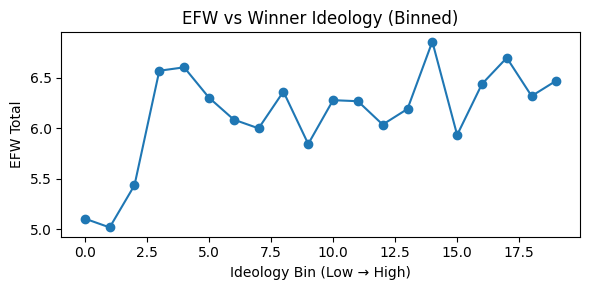

Binned Ideology Means (top 10)


,ideo_bin,efw_total
0,"(-4.281000000000001, -2.247]",5.106420
1,"(-2.247, -1.824]",5.019348
2,"(-1.824, -1.442]",5.436250
3,"(-1.442, -1.277]",6.567266
4,"(-1.277, -0.998]",6.600890
5,"(-0.998, -0.834]",6.301431
6,"(-0.834, -0.623]",6.084535
7,"(-0.623, -0.432]",5.998191
8,"(-0.432, -0.18]",6.361295
9,"(-0.18, 0.0385]",5.843603


EFW Δ(5y) by Elections in Prev 5y


,election_in_prev_5y,mean,count
0,False,0.055947,112
1,True,0.133471,1199


<Figure size 500x300 with 0 Axes>

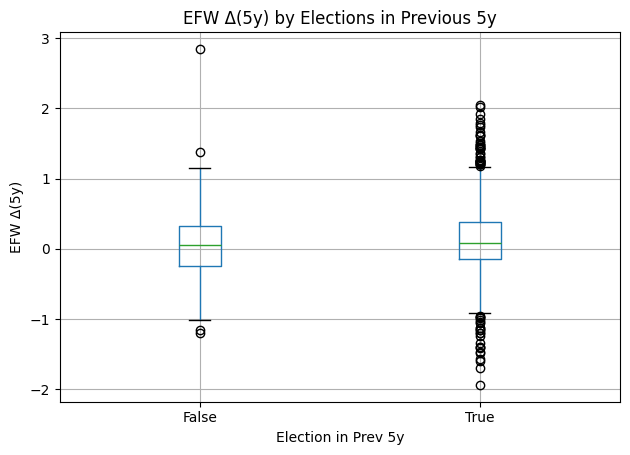

EFW Δ(5y) by Close Elections (5pp)


,last_close_5pp,mean,count
0,False,0.151806,341
1,True,0.049657,82


In [8]:
# Descriptive patterns

# EFW vs ideology (binned scatter)
if 'last_winner_ideo_vparty' in panel.columns:
    tmp = panel.dropna(subset=['last_winner_ideo_vparty','efw_total'])
    if len(tmp) > 0:
        tmp['ideo_bin'] = pd.qcut(tmp['last_winner_ideo_vparty'], q=20, duplicates='drop')
        binned = tmp.groupby('ideo_bin')['efw_total'].mean().reset_index()
        plt.figure(figsize=(6,3))
        plt.plot(range(len(binned)), binned['efw_total'], marker='o')
        plt.title('EFW vs Winner Ideology (Binned)')
        plt.xlabel('Ideology Bin (Low → High)')
        plt.ylabel('EFW Total')
        plt.tight_layout()
        plt.savefig(PATHS['reports'] / 'efw_quinquennial_audit' / 'figures' / 'efw_vs_ideology_binned.png', dpi=150)
        plt.show()
        show_table(binned.head(10), title='Binned Ideology Means (top 10)')

# EFW change around election timing
panel = panel.sort_values(['iso3','year'])
panel['efw_delta_5y'] = panel.groupby('iso3')['efw_total'].diff()

if 'election_in_prev_5y' in panel.columns:
    grp = panel.dropna(subset=['efw_delta_5y']).groupby('election_in_prev_5y')['efw_delta_5y'].agg(['mean','count']).reset_index()
    write_parquet_pyarrow(grp, PATHS['reports'] / 'efw_quinquennial_audit' / 'efw_delta_by_election_in_prev5y.parquet')
    show_table(grp, title='EFW Δ(5y) by Elections in Prev 5y')

    plt.figure(figsize=(5,3))
    panel.dropna(subset=['efw_delta_5y']).boxplot(column='efw_delta_5y', by='election_in_prev_5y')
    plt.title('EFW Δ(5y) by Elections in Previous 5y')
    plt.suptitle('')
    plt.xlabel('Election in Prev 5y')
    plt.ylabel('EFW Δ(5y)')
    plt.tight_layout()
    plt.savefig(PATHS['reports'] / 'efw_quinquennial_audit' / 'figures' / 'efw_delta_by_election_prev5y.png', dpi=150)
    plt.show()

# Close-election comparison
if 'last_close_5pp' in panel.columns:
    tmp = panel.dropna(subset=['efw_delta_5y','last_close_5pp'])
    grp = tmp.groupby('last_close_5pp')['efw_delta_5y'].agg(['mean','count']).reset_index()
    write_parquet_pyarrow(grp, PATHS['reports'] / 'efw_quinquennial_audit' / 'efw_delta_by_close5pp.parquet')
    show_table(grp, title='EFW Δ(5y) by Close Elections (5pp)')


In [9]:
# Save quinquennial panel and audit log
out_path = PATHS['data_processed'] / 'panel_efw_quinquennial.parquet'
write_parquet_pyarrow(panel, out_path)
print('wrote', out_path)

if AUDIT_LOG:
    audit_df = pd.DataFrame(AUDIT_LOG)
    write_parquet_pyarrow(audit_df, PATHS['reports'] / 'efw_quinquennial_audit' / 'audit_log.parquet')
    show_table(audit_df, title='Audit Log')


wrote /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/processed/panel_efw_quinquennial.parquet
Audit Log


,step,n_rows,n_cols,n_iso3,notes,n_dupe_rows_on_keys,left_rows,right_rows,merged_rows,matched_rows,left_only_rows,right_only_rows,on_keys,how
0,loaded_efw_quinquennial,1815.0,12.0,165.0,,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,loaded_elections_analysis,5511.0,84.0,162.0,,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,merged_efw_with_elections,1815.0,25.0,165.0,,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,merge_macro,NaN,NaN,NaN,NaN,NaN,1815.0,11718.0,1815.0,1804.0,11.0,0.0,"iso3,year",left
